In [1]:
# Hidden setup cell (imports, deterministic seed, global dt).
%matplotlib inline
import brainmass
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Seizure Dynamics with the Epileptor

The **Epileptor** (Jirsa et al., 2014) is the reference whole-brain model of epileptic seizures.
It is a six-dimensional system that couples a fast oscillatory subsystem, a slower
spike-and-wave subsystem, and — crucially — a **slow permittivity variable** `z` that evolves on
a much longer timescale. That slow variable autonomously ramps seizure-like discharges *on* and
then *off*, reproducing the stereotyped **onset / offset** structure of a focal seizure without
any external trigger.

This case study shows:

1. an epileptogenic node generating a full seizure cycle, with the LFP proxy `lfp = x2 − x1` and
   the hidden slow driver `z` plotted together,
2. how the **epileptogenicity parameter** `x0` separates healthy tissue from a seizure focus, and
3. the bifurcation it controls.

**Reference:** Jirsa, Stacey, Quilichini, Ivanov & Bernard (2014), *On the nature of seizure
dynamics*, Brain 137(8):2210-2230. The model is fully bundled in
{class}`~brainmass.EpileptorStep` — no external data is needed.

## 1. An epileptogenic node

`x0` sets the node's excitability (epileptogenicity). `x0 = -1.6` puts the node firmly in the
**seizing** regime, so it will discharge autonomously. The slow `z` is stiff, so we need a long
run (here 3 s at `dt = 0.1 ms`) for a complete onset → ictal → offset cycle to play out.

In [2]:
node = brainmass.EpileptorStep(in_size=1, x0=-1.6)
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(
    3000.0 * u.ms,
    monitors={'lfp': lambda m: m.lfp(), 'z': 'z', 'x1': 'x1'},
)
print("recorded steps:", res['lfp'].shape[0])
lfp_mag = u.get_magnitude(res['lfp'])
print(f"LFP range: [{lfp_mag.min():.2f}, {lfp_mag.max():.2f}]  (large excursions = ictal)")

recorded steps: 30000
LFP range: [-3.31, 2.45]  (large excursions = ictal)


## 2. The seizure and its hidden driver

Plotting the LFP proxy above the slow variable `z` reveals the mechanism: the LFP is quiescent,
then bursts into fast, high-amplitude discharges (the seizure), then returns to baseline. The
**timing of onset and offset is set entirely by the slow ramp of `z`** — the variable you cannot
see in an EEG but that the model exposes directly.

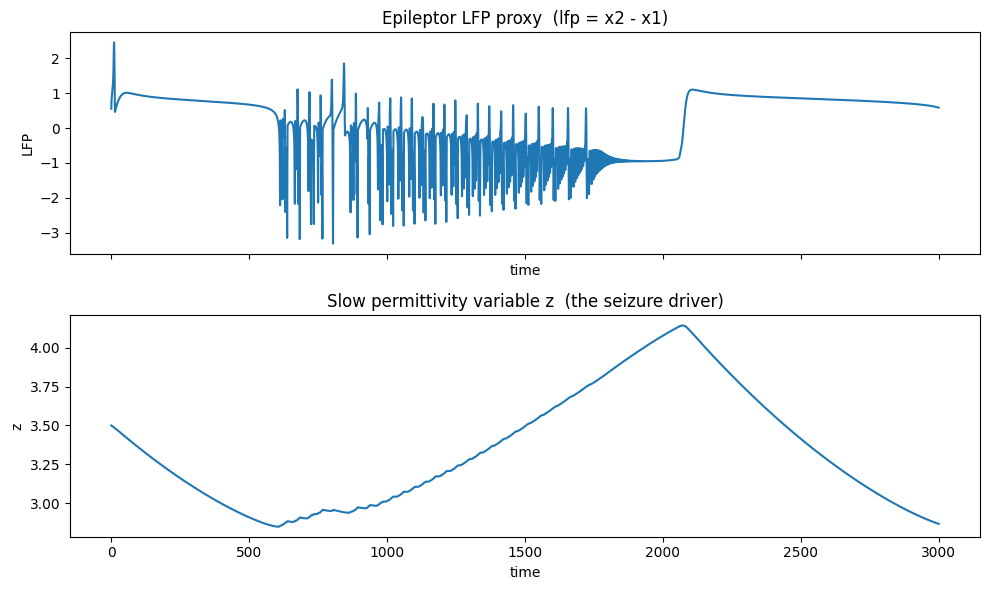

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
brainmass.viz.plot_timeseries(res['lfp'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Epileptor LFP proxy  (lfp = x2 - x1)')
axes[0].set_ylabel('LFP')
brainmass.viz.plot_timeseries(res['z'], ts=res['ts'], ax=axes[1])
axes[1].set_title('Slow permittivity variable z  (the seizure driver)')
axes[1].set_ylabel('z')
plt.tight_layout()
plt.show()

## 3. Epileptogenicity: healthy vs. seizure focus

The same node is **healthy** or a **seizure focus** depending only on `x0`. We sweep it across
the boundary (near `x0 ≈ -2.0`) and use the peak of the fast variable `x1` as a simple seizure
indicator: a healthy node keeps `x1` negative, a seizing node drives it positive.

In [4]:
records = {}
for x0 in [-2.4, -2.0, -1.8, -1.6]:
    m = brainmass.EpileptorStep(in_size=1, x0=x0)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        3000.0 * u.ms, monitors={'lfp': lambda mm: mm.lfp(), 'x1': 'x1'})
    x1max = float(np.max(u.get_magnitude(r['x1'])))
    state = 'SEIZING' if x1max > 0 else 'healthy'
    records[x0] = (r, x1max, state)
    print(f"x0 = {x0:+.1f}  ->  max(x1) = {x1max:+.3f}   ({state})")

x0 = -2.4  ->  max(x1) = -1.514   (healthy)
x0 = -2.0  ->  max(x1) = +1.813   (SEIZING)


x0 = -1.8  ->  max(x1) = +2.016   (SEIZING)
x0 = -1.6  ->  max(x1) = +2.047   (SEIZING)


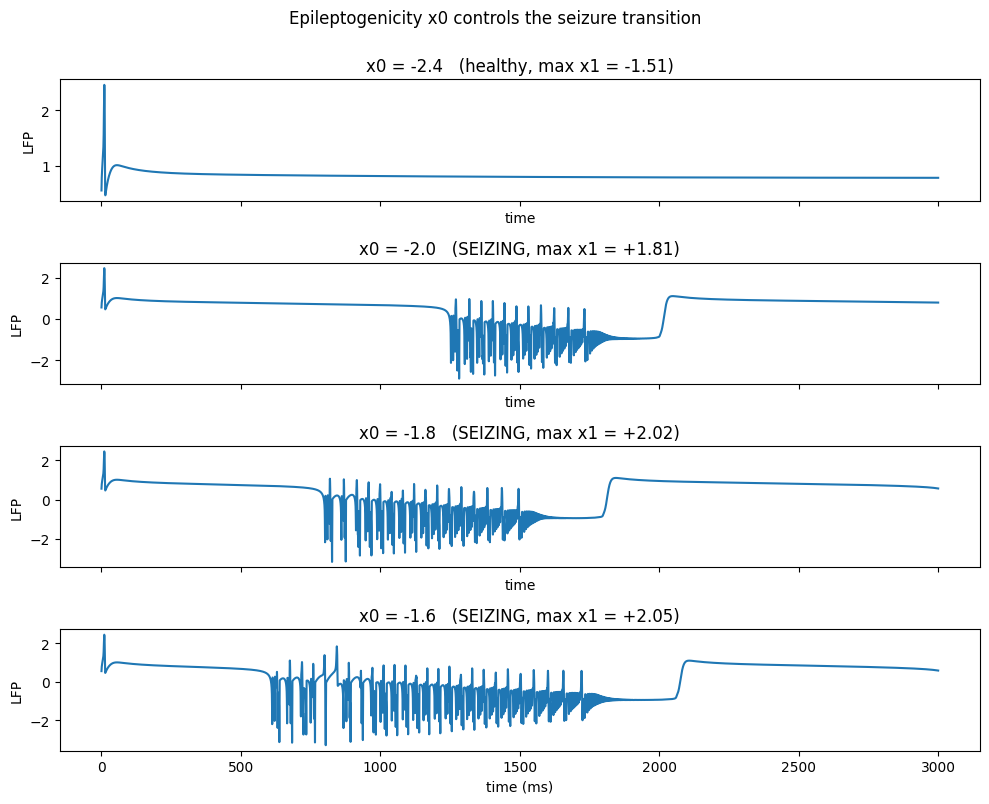

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for ax, (x0, (r, x1max, state)) in zip(axes, records.items()):
    brainmass.viz.plot_timeseries(r['lfp'], ts=r['ts'], ax=ax)
    ax.set_title(f'x0 = {x0:+.1f}   ({state}, max x1 = {x1max:+.2f})')
    ax.set_ylabel('LFP')
axes[-1].set_xlabel('time (ms)')
plt.suptitle('Epileptogenicity x0 controls the seizure transition', y=1.0)
plt.tight_layout()
plt.show()

## Summary

The Epileptor reproduces a full seizure from first principles:

- the **slow permittivity variable `z`** autonomously times seizure **onset and offset** — the
  LFP discharges ride on its slow ramp,
- the **epileptogenicity parameter `x0`** sets whether a node is healthy or a seizure focus,
  with a sharp transition near `x0 ≈ -2.0`, and
- {class}`~brainmass.EpileptorStep` exposes the `lfp()` observable (`x2 − x1`) that stands in for
  a recorded local field potential.

In a whole-brain study you would place Epileptor nodes on a connectome (via
{class}`~brainmass.Network`), make a subset of regions epileptogenic, and study how seizures
**recruit** and **propagate** through the network — the same construction as the resting-state
case study, with the Epileptor as the node.